### day10

check out the [file](./20260203.odt) for what was done before below topics

### requests module


In [2]:
import requests
dir(requests)

['ConnectTimeout',
 'ConnectionError',
 'DependencyWarning',
 'FileModeWarning',
 'HTTPError',
 'JSONDecodeError',
 'NullHandler',
 'PreparedRequest',
 'ReadTimeout',
 'Request',
 'RequestException',
 'RequestsDependencyWarning',
 'Response',
 'Session',
 'Timeout',
 'TooManyRedirects',
 'URLRequired',
 '__author__',
 '__author_email__',
 '__build__',
 '__builtins__',
 '__cached__',
 '__cake__',
 '__copyright__',
 '__description__',
 '__doc__',
 '__file__',
 '__license__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__title__',
 '__url__',
 '__version__',
 '_check_cryptography',
 '_internal_utils',
 'adapters',
 'api',
 'auth',
 'certs',
 'chardet_version',
 'charset_normalizer_version',
 'check_compatibility',
 'codes',
 'compat',
 'cookies',
 'delete',
 'exceptions',
 'get',
 'head',
 'hooks',
 'logging',
 'models',
 'options',
 'packages',
 'patch',
 'post',
 'put',
 'request',
 'session',
 'sessions',
 'ssl',
 'status_codes',
 'structures',
 'urllib3',
 

In [3]:
print(dir(requests.session))

['__annotations__', '__builtins__', '__call__', '__class__', '__closure__', '__code__', '__defaults__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__get__', '__getattribute__', '__getstate__', '__globals__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__kwdefaults__', '__le__', '__lt__', '__module__', '__name__', '__ne__', '__new__', '__qualname__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__type_params__']


In [4]:
####### weatherapi.com api
api_key = "29479cfbd3124ae08a763435260302"
q = input("city name: ")
base_url = ""
req = ""

if req == "current":
    pass


params = {
    "key: api_key,
    "q": q,
    "lang": "en"
}

## high level abstraction through requests module to formulate the request parameter
response = requests.get(complete_url, params=params)

print(response.status_code) # the code, for eg 200 for ok status
print(response.ok) # true / false

print(dir(response))

print(response.url) # complete URL

print(response.text) # gives `str` json, we'v got to process this

print(json.loads(response.text))
# or
print(response.json())

### got an error and want to inspect the request for the corresponding response
req = response.request
print(req.url)
print(req.path_url)


SyntaxError: unterminated string literal (detected at line 10) (2772954431.py, line 10)

In [36]:
### some practice on requests module
base_url = "https://api.open-meteo.com/v1/"
api_endpoint = "forecast"

cities = {
    "hyderabad": (17.4065,78.4772),
    "delhi": (28.6139, 77.2090),
    "kolkata": (122.5726, 88.3639),
    "chennai": (13.0827,80.2707),
    "mumbai": (19.0760, 72.8777)
}

city_coords = cities[target_city]

In [37]:
params = {
    "latitude": city_coords[0],
    "longitude": city_coords[1],
    "current": "temperature_2m"
}

In [38]:
res = requests.get(base_url+api_endpoint, params=params)

In [39]:
if res.ok and res.status_code == 200:
    data = res.json()
else:
    print(f"error: {res.status_code}")

In [40]:
temperature = data["current"]["temperature_2m"]
temp_unit = data["current_units"]["temperature_2m"]
print(f"Temperature in {target_city} is {temperature}{temp_unit}.")

Temperature in hyderabad is 27.3°C.


In [150]:
base_url = "https://api.open-meteo.com/v1/"
api_endpoint = "forecast"

cities = {
    # add cities in this dihhtionary
    "hyderabad": (17.4065,78.4772),
    "delhi": (28.6139, 77.2090),
    "kolkata": (22.5726, 88.3639),
    "chennai": (13.0827,80.2707),
    "mumbai": (19.0760, 72.8777)
}

In [49]:
for city, coords in cities.items():
    params = {
        "latitude": coords[0],
        "longitude": coords[1],
        "current": "temperature_2m"
    }

    res = requests.get(base_url+api_endpoint, params)

    if res.ok and res.status_code == 200:
        data = res.json()
        temperature = data["current"]["temperature_2m"]
        temp_unit = data["current_units"]["temperature_2m"]
        print(f"Temperature in {city} is {temperature}{temp_unit}.")
    else:
        print(f"Error in fetching data for {city}. Error code: {res.status_code}")

Temperature in hyderabad is 27.3°C.
Temperature in delhi is 19.2°C.
Temperature in kolkata is 25.3°C.
Temperature in chennai is 28.6°C.
Temperature in mumbai is 26.4°C.


In [70]:
##### normal distribution values
import random
from math import cos, log, sqrt, pi

In [145]:
def normal_value(mu=0, sigma=1,discrete=False):
    u1, u2 = random.random(), random.random()
    u1 = max(u1, 1e-12)
    x = mu + sigma*sqrt(-2.0 * log(u1))*cos(2*pi*u2) # box muller formula
    return round(x) if discrete else x

In [148]:
nsample = int(input("Enter number of samples you want: "))
mean = float(input("Enter mean value: "))
std = float(input("Enter standard dev value: "))
samples = [normal_value(mean, std, 0) for x in range(nsample)]

Enter number of samples you want:  1000
Enter mean value:  -1
Enter standard dev value:  10


In [124]:
import matplotlib.pyplot as plt

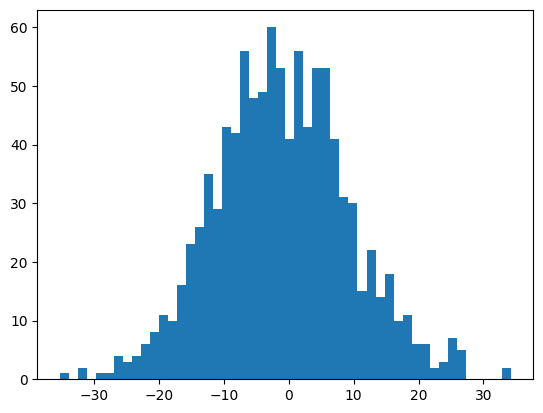

In [149]:
plt.hist(samples,bins=50)
plt.show()